In [1]:
import cdms
import numpy as np
import os, sys 
import re
import ROOT
import array
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
# functions to get relative calibration factors
def read_file(file_path):
    with open(file_path, 'r') as file:
        return file.read()

def extract_channel_order(text):
    channel_order_pattern = re.compile(r'P[ABCDEF][S][12]')
    match = channel_order_pattern.findall(text)
    if match:
        return match
    return []

def extract_calibration_data(text, channel_order):
    pattern = re.compile(r'PARAMETER_DOUBLE\s+P_RELATIVE_CALIBRATION\s+DETECTOR\s+(\d+)\s+=\s+([\d\s.]+)')
    matches = pattern.findall(text)
    
    calibration_data = {}
    
    for match in matches:
        detector_number = int(match[0])
        values = list(map(float, match[1].split()))
        calibration_data[detector_number] = dict(zip(channel_order, values))
    
    return calibration_data

def get_rel_calib(file_path): 
    """
    Finds relative calibration factors in a cdmsbats configuration file
    Parameters: 
        file_path: str, file path to config file.
    Returns: 
        dictionary of relative calibration factors for each detector. 
        Can access using get_rel_calib(file_path)[int(det_number)][str(channel)]
    """
    text = read_file(file_path)
    channel_order = extract_channel_order(text)
    if not channel_order:
        print("Channel order not found...")
        return
    
    calibration_data = extract_calibration_data(text, channel_order)
    return calibration_data

In [3]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [4]:
DMCfiles = np.sort(glob.glob('/scratch/group/mitchcomp/CDMS/data/perry5334/Ge71_Kshell_50V_100kEvents/DMCOutput/R?/Ge71_Kshell_????????_000???.root'))

In [5]:
# Sort by the last 3 characters
DMCfiles = sorted(DMCfiles, key=lambda s: float(s[-8:-5]))

In [6]:
g4dmcHits = CDataFrame('G4SimDir/g4dmcHits', DMCfiles)
EventNum = g4dmcHits.AsNumpy(['EventNum'])['EventNum']
X = g4dmcHits.AsNumpy(['X'])['X']*1e3
Y = g4dmcHits.AsNumpy(['Y'])['Y']*1e3
Z = g4dmcHits.AsNumpy(['Z'])['Z']*1e3

R = np.sqrt(X**2 + Y**2)

In [4]:
RQfiles = np.sort(glob.glob("/scratch/group/mitchcomp/CDMS/data/perry5334/Ge71_Kshell_50V_100kEvents/Processed_noise_triangle/R?/Unmerged/5125????_000000/Test_5125????_000000_F0???.root"))

In [5]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), RQfiles, friends = [[x+":rqDir/eventTree" for x in RQfiles]])

In [6]:
## Apply some basic data quality filters and get the RQs you're interested in
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(0), "PTOFamps>0"])

channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQs = ["SeriesNumber", "EventNumber", "PTOFamps", "PTOFchisqLF"] + [chan + "OFamps" for chan in channels] + [chan + "OFchisqLF" for chan in channels]
df_rqs = df_filtered.AsNumpy(RQs + ['EventTriggerID'])

In [7]:
def linearize(x):
    return 1/b * (np.exp(x / a) - 1)

def pt2keV(x):
    lin_pt = linearize(x)
    recoilE = lin_pt * calibFac / LukeFac
    return recoilE

In [8]:
a, b = 2.08e-04, 1.63e+01
calibFac = 21000
LukeFac = 1 + 50 / 3
df_rqs['PTOFamps_keVee'] = pt2keV(df_rqs['PTOFamps']*10/4)

In [9]:
relative_calibration_path = '/scratch/group/mitchcomp/CDMS/data/perry5334/processing/cdmsbats_config/UserSettings/BatRootSettings/analysis/DMCData.HV100mm_uni_triangle'

rel_calibs = get_rel_calib(relative_calibration_path)

In [10]:
det = 1
Fsum = df_rqs['PFS1OFamps']*rel_calibs[det]['PFS1'] + df_rqs['PFS2OFamps']*rel_calibs[det]['PFS2']
Asum = df_rqs['PAS1OFamps']*rel_calibs[det]['PAS1'] + df_rqs['PAS2OFamps']*rel_calibs[det]['PAS2']
RadialPar = (Fsum - Asum) / df_rqs['PTOFamps']

In [11]:
ROOT.gStyle.SetOptStat(0)

stops = array.array('d', [0.0, 1.0])      # Gradient positions (normalized)
red   = array.array('d', [0.0, 1.0])      # R: from 0 to 1
green = array.array('d', [0.0, 1.0])      # G: from 0 to 1
blue  = array.array('d', [1.0, 1.0])      # B: stays at 1

n_colors = 256

ROOT.TColor.CreateGradientColorTable(len(stops), stops, red, green, blue, n_colors)
ROOT.gStyle.SetNumberContours(n_colors)

g = ROOT.TGraph2D(len(R), R, Z, RadialPar)
g.SetTitle(" ;R position [mm];Z position [mm];Radial Parameter")

g.GetXaxis().SetLabelSize(0.05)
g.GetYaxis().SetLabelSize(0.05)
g.GetXaxis().SetTitleSize(0.05)
g.GetYaxis().SetTitleSize(0.05)

c = ROOT.TCanvas("c", "Canvas", 1000, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.25)
c.SetRightMargin(0.15)
c.SetTopMargin(0.05)
g.SetNpx(100)
g.SetNpy(100)
g.SetMarginBinsContent(-999)
g.SetMinimum(min(RadialPar))
g.Draw("COLZ")
c.Draw()

NameError: name 'R' is not defined

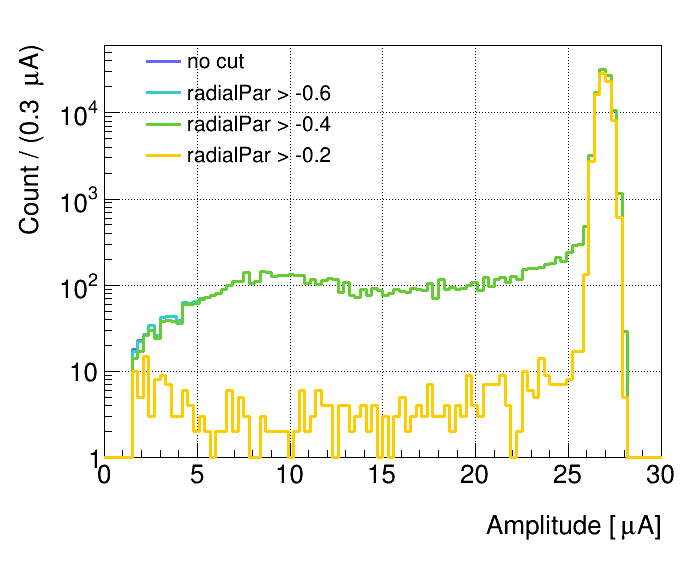

In [12]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 30
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

h1 = ROOT.TH1F("h1", f" ;Amplitude [#muA];Count / ({bindiff} #muA)", nbins, bins_start, bins_end)
data1 = df_rqs['PTOFamps']*10/4*1e6

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-7)

h2 = ROOT.TH1F("h2", f"; ; ", nbins, bins_start, bins_end)
data2 = df_rqs['PTOFamps'][RadialPar > -0.6]*10/4*1e6

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kCyan-3)

h3 = ROOT.TH1F("h3", f"; ; ", nbins, bins_start, bins_end)
data3 = df_rqs['PTOFamps'][RadialPar > -0.4]*10/4*1e6

for value in data3:
    h3.Fill(value)
h3.SetLineWidth(3)
h3.SetLineColor(ROOT.kSpring-5)

h4 = ROOT.TH1F("h4", f"; ; ", nbins, bins_start, bins_end)
data4 = df_rqs['PTOFamps'][RadialPar > -0.2]*10/4*1e6

for value in data4:
    h4.Fill(value)
h4.SetLineWidth(3)
h4.SetLineColor(ROOT.kOrange)
    
h1.SetMinimum(1)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

legend = ROOT.TLegend(0.2, 0.7, 0.48, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "no cut", "l")
legend.AddEntry(h2, "radialPar > -0.6", "l")
legend.AddEntry(h3, "radialPar > -0.4", "l")
legend.AddEntry(h4, "radialPar > -0.2", "l")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.15)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
h2.Draw("SAME")
h3.Draw("SAME")
h4.Draw("SAME")
legend.Draw()
c.SetGrid(1,1)
c.SetLogy()
c.Draw()

Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


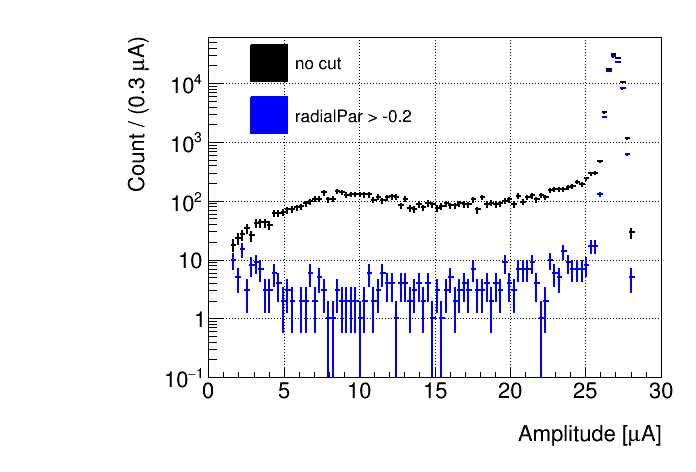

In [31]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 30
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

h1 = ROOT.TH1F("h1", f" ;Amplitude [#muA];Count / ({bindiff} #muA)", nbins, bins_start, bins_end)
data1 = df_rqs['PTOFamps']*10/4*1e6

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(2)
h1.SetLineColor(ROOT.kBlack)
h1.SetFillColor(ROOT.kBlack)
h1.SetMinimum(0.1)

h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

h2 = ROOT.TH1F("h2", f"; ; ", nbins, bins_start, bins_end)
data2 = df_rqs['PTOFamps'][RadialPar > -0.2]*10/4*1e6

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(2)
h2.SetLineColor(ROOT.kBlue)
h2.SetFillColor(ROOT.kBlue)

legend = ROOT.TLegend(0.35, 0.7, 0.65, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "no cut", "f")
legend.AddEntry(h2, "radialPar > -0.2", "f")

c = ROOT.TCanvas("c", "RooFit Plot", 700, 500)
h1.Draw("E0")
h2.Draw("E0 SAME")
legend.Draw()

c.SetLeftMargin(0.3)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1,1)
c.SetLogy()
c.Draw()

Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


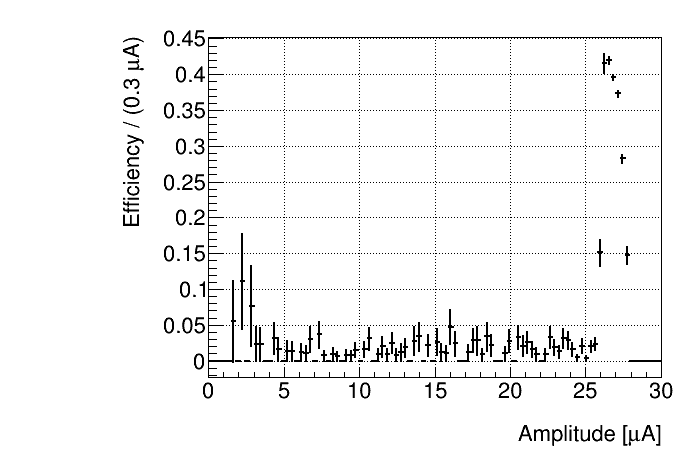

In [43]:
threshold = -0.0

ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 30
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

h1 = ROOT.TH1F("h1", f" ;Amplitude [#muA];Efficiency / ({bindiff} #muA)", nbins, bins_start, bins_end)
data1 = df_rqs['PTOFamps']*10/4*1e6

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(2)
h1.SetLineColor(ROOT.kBlack)

h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

h2 = ROOT.TH1F("h2", f"; ; ", nbins, bins_start, bins_end)
data2 = df_rqs['PTOFamps'][RadialPar > threshold]*10/4*1e6

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(2)
h2.SetLineColor(ROOT.kBlue)

h3 = h1.Clone("residual")
h3.Reset()

nbins = h1.GetNbinsX()

for i in range(1, nbins + 1):
    h1_val = h1.GetBinContent(i)
    h2_val = h2.GetBinContent(i)
    h1_err = h1.GetBinError(i)
    h2_err = h2.GetBinError(i)
    
    if h1_val != 0:
        rel_diff = h2_val / h1_val
        rel_diff_err = ((h2_err/h1_val)**2 + (h2_val / h1_val**2 * h1_err)**2) ** 0.5
    else:
        rel_diff = 0
        rel_diff_err = 0
    
    h3.SetBinContent(i, rel_diff)
    h3.SetBinError(i, rel_diff_err)

h3.SetLineWidth(2)
h3.GetXaxis().SetLabelSize(0.05)
h3.GetYaxis().SetLabelSize(0.05)
h3.GetXaxis().SetTitleSize(0.05)
h3.GetXaxis().SetTitleOffset(1.5)
h3.GetYaxis().SetTitleSize(0.05)

c = ROOT.TCanvas("c", "RooFit Plot", 700, 500)
h3.Draw("E0")

c.SetLeftMargin(0.3)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1,1)
c.Draw()